# Système d'Aide à la Décision — Rétention Client (Anti-Churn)
---
> **Domaine métier :** E-commerce  
> **Phase :** 1 — Définition du Problème, KPIs & Business Case

## 1. Question Décisionnelle Centrale

**Quels sont les facteurs prédictifs de l'attrition (churn) à 90 jours, et comment utiliser ces signaux pour identifier et retenir proactivement les clients à risque ?**

Cette question constitue le fil directeur de l'ensemble du projet. Elle implique à la fois :
- une **dimension analytique** (identification des facteurs de churn),
- une **dimension opérationnelle** (actions de rétention ciblées et proactives).

## 2. Définition des KPIs

### 2.1 KPIs Primaires — Niveau Stratégique & Financier

Ces indicateurs de haut niveau intéressent directement la direction. Ils mesurent l'impact global de la solution sur la santé de l'entreprise.

| KPI | Définition | Objectif |
|-----|-----------|----------|
| **Taux d'attrition (Churn Rate) à 90 jours** | % de clients actifs n'ayant effectué aucun achat au cours des 90 derniers jours | Indicateur fondamental du problème décisionnel |
| **Chiffre d'Affaires (CA) Sauvegardé** | Revenu généré par les clients identifiés « à fort risque de churn » ayant finalement réalisé un achat suite à une action de rétention | Mesure l'impact financier direct de la solution |

### 2.2 KPIs Secondaires — Niveau Opérationnel & Comportemental

Ces indicateurs aident à comprendre les causes sous-jacentes du churn et à évaluer l'efficacité des actions concrètes mises en place.

| KPI | Définition | Signal |
|-----|-----------|--------|
| **Récence moyenne** | Nombre moyen de jours écoulés depuis la dernière transaction d'un client | L'un des signaux prédictifs les plus forts de l'attrition |
| **Taux de conversion des campagnes ciblées** | % de clients « à risque » ayant utilisé un code promo ou cliqué sur une recommandation de rétention | Efficacité opérationnelle des campagnes |
| **Fréquence de visite sans achat** | Nombre de connexions/navigations sans finalisation de panier | Indicateur de friction (prix, UX, frais de port) |

## 3. KPI Tree — Arbre Hiérarchique des Indicateurs

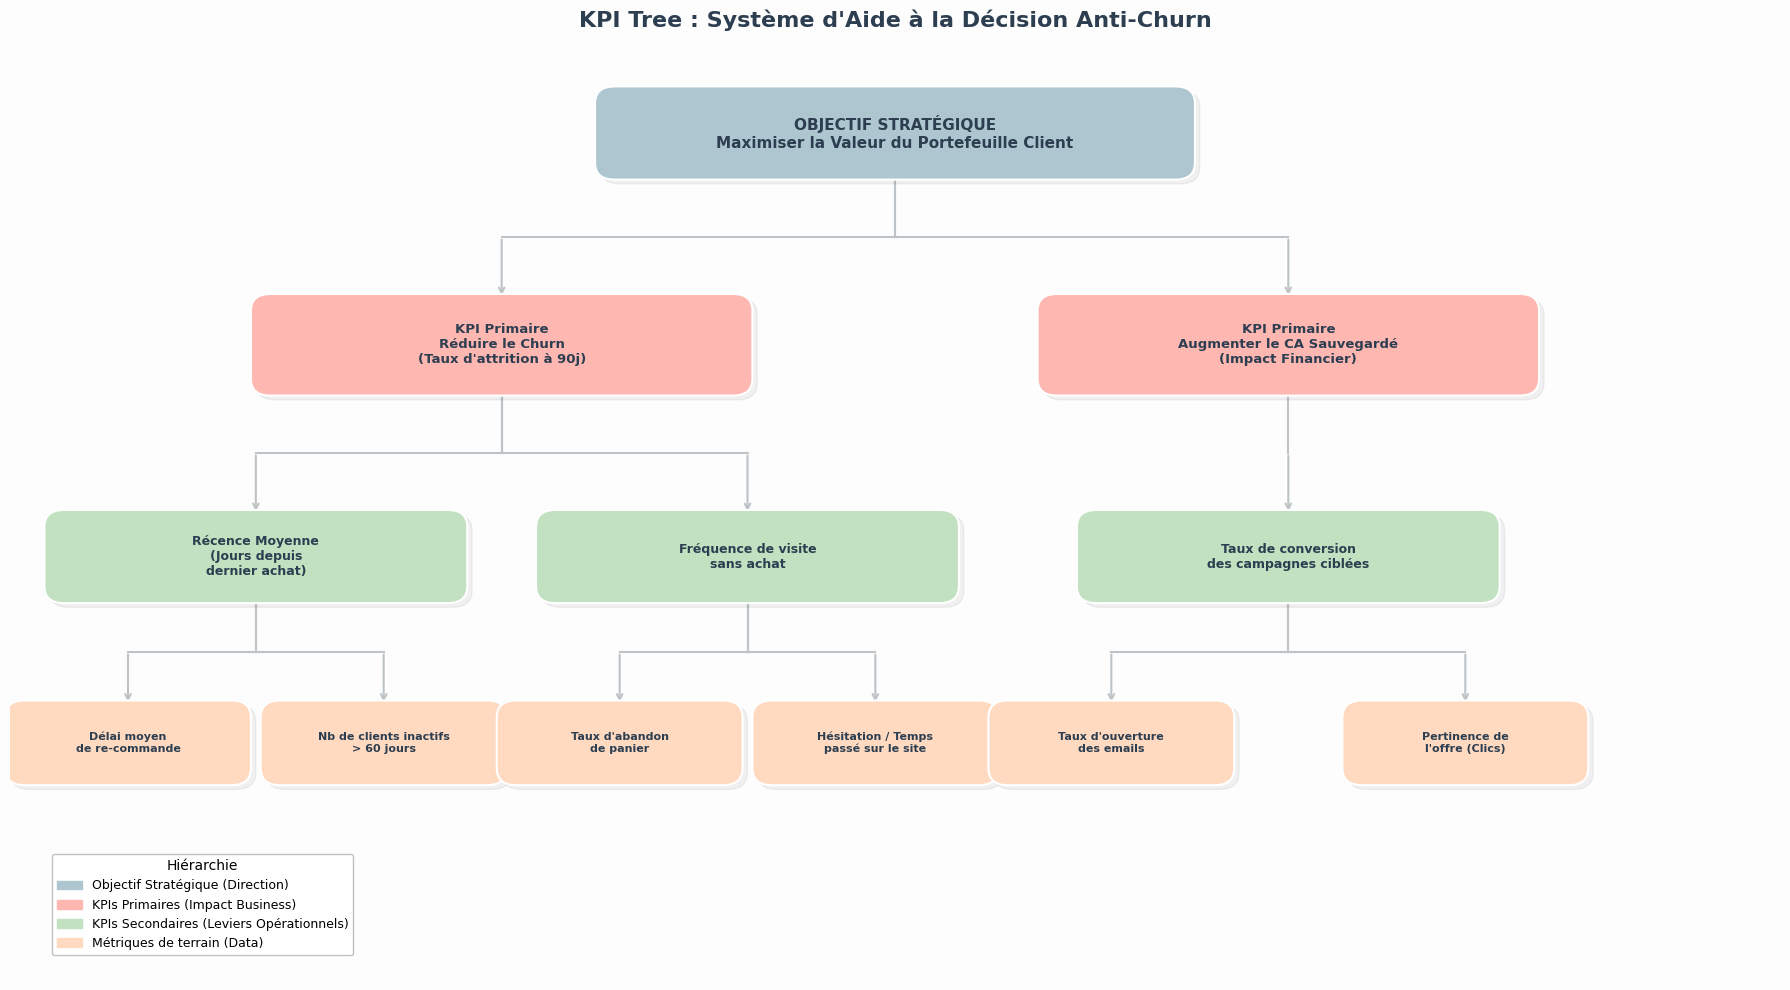

KPI Tree généré et sauvegardé → kpi_tree.png


In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(18, 10))
ax.set_xlim(0, 18)
ax.set_ylim(0, 11)
ax.axis('off')
fig.patch.set_facecolor('#FDFDFD') # Fond très clair, presque blanc

# ── Palette de couleurs (Pastel) ──────────────────────────────────────────────
C_STRAT  = '#AEC6CF'   # Bleu pastel doux
C_PRI    = '#FFB7B2'   # Rose / Saumon pastel
C_SEC    = '#C1E1C1'   # Vert d'eau pastel
C_LEAF   = '#FFDAC1'   # Pêche pastel
C_TEXT   = '#2C3E50'   # Gris anthracite foncé (pour la lisibilité sur fond clair)
C_LINE   = '#BDC3C7'   # Gris argenté doux pour les connecteurs

def draw_box_pastel(ax, x, y, w, h, text, color, fontsize=9, radius=0.2):
    # Ombre très légère pour détacher la boîte du fond
    shadow = mpatches.FancyBboxPatch(
        (x - w/2 + 0.05, y - h/2 - 0.05), w, h,
        boxstyle=f"round,pad=0.05,rounding_size={radius}",
        facecolor='black', alpha=0.05, zorder=2
    )
    ax.add_patch(shadow)
    
    # Boîte principale avec couleur pastel
    fancy = mpatches.FancyBboxPatch(
        (x - w/2, y - h/2), w, h,
        boxstyle=f"round,pad=0.05,rounding_size={radius}",
        linewidth=1.5, edgecolor='white',
        facecolor=color, zorder=3
    )
    ax.add_patch(fancy)
    
    # Texte en gris foncé/noir pour bien ressortir
    ax.text(x, y, text, ha='center', va='center',
            color=C_TEXT, fontsize=fontsize,
            fontweight='bold', wrap=True,
            multialignment='center', zorder=4)

def draw_elbow_line(ax, x1, y1, x2, y2):
    """Dessine une ligne coudée avec la couleur des connecteurs définie."""
    mid_y = (y1 + y2) / 2
    ax.plot([x1, x1], [y1, mid_y], color=C_LINE, lw=1.5, zorder=1)
    ax.plot([x1, x2], [mid_y, mid_y], color=C_LINE, lw=1.5, zorder=1)
    ax.annotate('', xy=(x2, y2), xytext=(x2, mid_y),
                arrowprops=dict(arrowstyle='->', color=C_LINE, lw=1.5), zorder=1)

# ── Niveau 0 : Objectif Stratégique ───────────────────────────────────────────
draw_box_pastel(ax, 9, 10, 6.0, 1.0,
         'OBJECTIF STRATÉGIQUE\nMaximiser la Valeur du Portefeuille Client',
         C_STRAT, fontsize=11)

# ── Niveau 1 : KPIs Primaires ─────────────────────────────────────────────────
pri = [
    (5,   7.5, 'KPI Primaire\nRéduire le Churn\n(Taux d\'attrition à 90j)'),
    (13,  7.5, 'KPI Primaire\nAugmenter le CA Sauvegardé\n(Impact Financier)'),
]
for (x, y, lbl) in pri:
    draw_box_pastel(ax, x, y, 5.0, 1.1, lbl, C_PRI, fontsize=9.5)
    draw_elbow_line(ax, 9, 9.5, x, 8.05)

# ── Niveau 2 : KPIs Secondaires ───────────────────────────────────────────────
sec = [
    (2.5,  5.0, 'Récence Moyenne\n(Jours depuis\ndernier achat)'),
    (7.5,  5.0, 'Fréquence de visite\nsans achat'),
    (13.0, 5.0, 'Taux de conversion\ndes campagnes ciblées'),
]
parents = [(5, 6.95), (5, 6.95), (13, 6.95)]
for i, (x, y, lbl) in enumerate(sec):
    draw_box_pastel(ax, x, y, 4.2, 1.0, lbl, C_SEC, fontsize=9)
    px, py = parents[i]
    draw_elbow_line(ax, px, py, x, 5.5)

# ── Niveau 3 : Drivers Opérationnels ──────────────────────────────────────────
leaves = [
    (1.2,  2.8, 'Délai moyen\nde re-commande'),
    (3.8,  2.8, 'Nb de clients inactifs\n> 60 jours'),
    (6.2,  2.8, 'Taux d\'abandon\nde panier'),
    (8.8,  2.8, 'Hésitation / Temps\npassé sur le site'),
    (11.2, 2.8, 'Taux d\'ouverture\ndes emails'),
    (14.8, 2.8, 'Pertinence de\nl\'offre (Clics)'),
]
leaf_parents = [
    (2.5, 4.5), (2.5, 4.5),
    (7.5, 4.5), (7.5, 4.5),
    (13.0,4.5), (13.0,4.5),
]
for i, (x, y, lbl) in enumerate(leaves):
    draw_box_pastel(ax, x, y, 2.4, 0.9, lbl, C_LEAF, fontsize=8)
    px, py = leaf_parents[i]
    draw_elbow_line(ax, px, py, x, 3.25)

# ── Légende ───────────────────────────────────────────────────────────────────
legend_items = [
    mpatches.Patch(color=C_STRAT,  label='Objectif Stratégique (Direction)'),
    mpatches.Patch(color=C_PRI,    label='KPIs Primaires (Impact Business)'),
    mpatches.Patch(color=C_SEC,    label='KPIs Secondaires (Leviers Opérationnels)'),
    mpatches.Patch(color=C_LEAF,   label='Métriques de terrain (Data)'),
]
ax.legend(handles=legend_items, loc='lower left', bbox_to_anchor=(0.02, 0.02),
          fontsize=9, framealpha=1, title='Hiérarchie', 
          edgecolor=C_LINE)

ax.set_title('KPI Tree : Système d\'Aide à la Décision Anti-Churn',
             fontsize=16, fontweight='bold', pad=15, color=C_TEXT)

plt.tight_layout()
plt.savefig('kpi_tree.png', dpi=300, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print('KPI Tree généré et sauvegardé → kpi_tree.png')

## 4. Business Case — Système d'Aide à la Décision pour la Rétention Client

### 4.1 Contexte et Problématique

Notre plateforme e-commerce fait face à une **perte continue d'une partie de sa base de clients actifs** à un horizon de 90 jours (attrition ou *churn*). Actuellement, les actions marketing de fidélisation sont :

- **Globales** : sans distinction entre les segments clients,
- **Réactives** : déclenchées après le départ constaté, et non en amont,
- **Indifférenciées** : sans prise en compte des facteurs réels de départ.

Plus critique encore, nous manquons de visibilité sur les **véritables facteurs** qui poussent nos clients au départ (délais de livraison, tarification, expérience utilisateur). Cette méconnaissance :
- empêche d'adapter la stratégie globale,
- engendre des **coûts d'acquisition et de rétention élevés** pour un impact limité.

### 4.2 Solution Data-Driven Proposée

Le projet consiste à déployer un **système d'aide à la décision complet**, de l'extraction des données à la mesure d'impact, comprenant :

| Composant | Description |
|-----------|-------------|
| **Centralisation & Audit** | Entrepôt de données exploitant un historique transactionnel robuste (> 540 000 lignes de données réelles) |
| **Exploration & Interprétabilité** | EDA approfondie + méthodes d'interprétabilité (valeurs SHAP globales & locales) pour extraire les facteurs prédictifs majeurs |
| **Modélisation Prédictive** | Algorithme de classification identifiant proactivement les clients à risque dans les 90 prochains jours |
| **Visualisation** | Dashboard interactif permettant à la direction et aux équipes opérationnelles de piloter les KPIs et cibler les campagnes |

### 4.3 Évaluation Financière & Calcul du ROI Prévisionnel

La projection mensuelle s'appuie sur une base de **50 000 clients actifs** et un panier moyen représentatif du marché.

In [2]:
# ── Paramètres de base ────────────────────────────────────────────────────────
clients_actifs      = 50_000   # Base clients
taux_churn_mensuel  = 0.05     # 5% de churn estimé
panier_moyen        = 500      # £

# ── A. Situation initiale (coût de l'inaction) ────────────────────────────────
clients_perdus      = clients_actifs * taux_churn_mensuel
manque_a_gagner     = clients_perdus * panier_moyen

# ── B. Impact de la solution ──────────────────────────────────────────────────
taux_detection      = 0.80     # Précision du modèle ML
taux_conversion     = 0.15     # Taux de conversion campagnes hyper-personnalisées

clients_cibles      = clients_perdus * taux_detection
clients_sauvegardes = clients_cibles  * taux_conversion
ca_sauvegarde       = clients_sauvegardes * panier_moyen

# ── C. Coûts ─────────────────────────────────────────────────────────────────
cout_infra          = 15_000   # £/mois – Cloud & ML
cout_marketing      = 25_000   # £/mois – Avantages commerciaux
investissement_total= cout_infra + cout_marketing

# ── D. ROI ───────────────────────────────────────────────────────────────────
benefice_net        = ca_sauvegarde - investissement_total
roi                 = (benefice_net / investissement_total) * 100

# ── Affichage ────────────────────────────────────────────────────────────────
separator = '─' * 52
print(separator)
print('   ÉVALUATION FINANCIÈRE — SYSTÈME ANTI-CHURN')
print(separator)
print(f'\n* A. Situation initiale (Coût de l\'inaction)')
print(f'   Base clients actifs          : {clients_actifs:>10,} clients')
print(f'   Taux de churn mensuel        : {taux_churn_mensuel*100:>9.0f} %')
print(f'   Clients perdus / mois        : {clients_perdus:>10,.0f} clients')
print(f'   Manque à gagner brut/mois    : {manque_a_gagner:>10,.0f} £')
print(f'\n* B. Impact de la solution Data')
print(f'   Taux de détection du modèle  : {taux_detection*100:>9.0f} %')
print(f'   Clients à risque ciblés      : {clients_cibles:>10,.0f} clients')
print(f'   Taux conversion campagnes    : {taux_conversion*100:>9.0f} %')
print(f'   Clients sauvegardés / mois   : {clients_sauvegardes:>10,.0f} clients')
print(f'   CA Sauvegardé (Gain brut)    : {ca_sauvegarde:>10,.0f} £')
print(f'\n* C. Coûts d\'investissement')
print(f'   Infrastructure Cloud & ML    : {cout_infra:>10,.0f} £ / mois')
print(f'   Coûts opérationnels marketing: {cout_marketing:>10,.0f} £ / mois')
print(f'   Investissement total / mois  : {investissement_total:>10,.0f} £ / mois')
print(f'\n{separator}')
print(f'* D. Calcul du ROI')
print(f'   Bénéfice net mensuel         : {benefice_net:>10,.0f} £')
print(f'   ROI Prévisionnel             : {roi:>10.0f} %')
print(separator)

────────────────────────────────────────────────────
   ÉVALUATION FINANCIÈRE — SYSTÈME ANTI-CHURN
────────────────────────────────────────────────────

* A. Situation initiale (Coût de l'inaction)
   Base clients actifs          :     50,000 clients
   Taux de churn mensuel        :         5 %
   Clients perdus / mois        :      2,500 clients
   Manque à gagner brut/mois    :  1,250,000 £

* B. Impact de la solution Data
   Taux de détection du modèle  :        80 %
   Clients à risque ciblés      :      2,000 clients
   Taux conversion campagnes    :        15 %
   Clients sauvegardés / mois   :        300 clients
   CA Sauvegardé (Gain brut)    :    150,000 £

* C. Coûts d'investissement
   Infrastructure Cloud & ML    :     15,000 £ / mois
   Coûts opérationnels marketing:     25,000 £ / mois
   Investissement total / mois  :     40,000 £ / mois

────────────────────────────────────────────────────
* D. Calcul du ROI
   Bénéfice net mensuel         :    110,000 £
   ROI Prévisi

### 4.4 Formule du ROI

$$\text{ROI} = \frac{\text{CA Sauvegardé} - \text{Investissement Total}}{\text{Investissement Total}} \times 100$$

$$\text{ROI} = \frac{150\,000\text{ £} - 40\,000\text{ £}}{40\,000\text{ £}} \times 100 = \frac{110\,000}{40\,000} \times 100 = \mathbf{275\%}$$

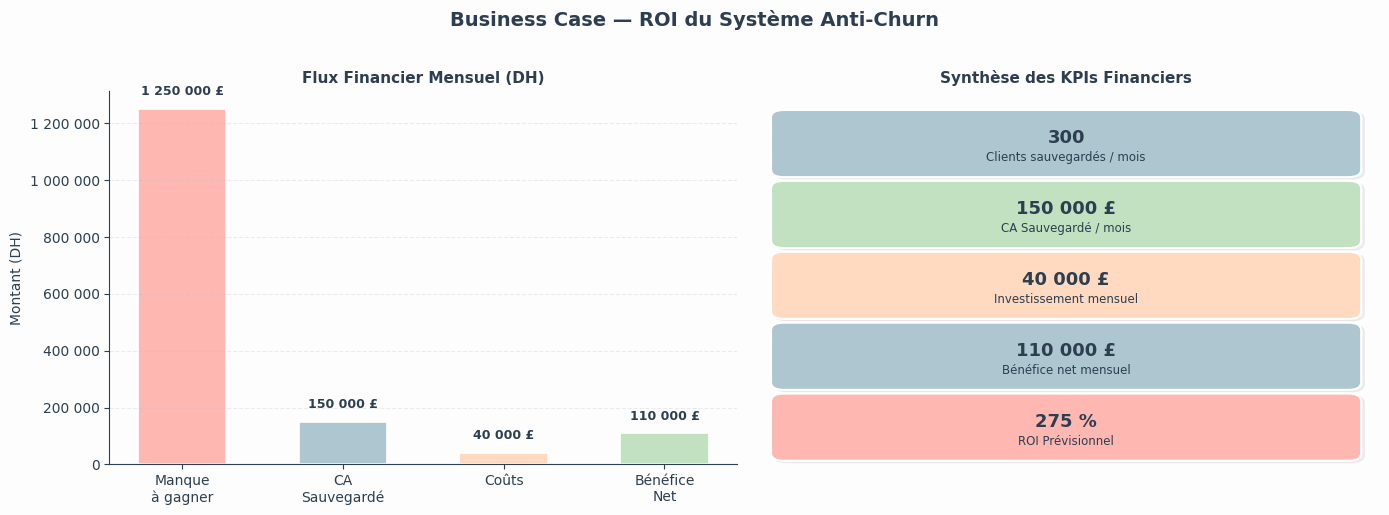

Graphique ROI généré → business_case_roi.png


In [3]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import numpy as np

# ── Variables de démonstration (à remplacer par vos données) ──────────────────
manque_a_gagner = 1250000
ca_sauvegarde = 150000
investissement_total = 40000
benefice_net = 110000
clients_sauvegardes = 300
roi = 275

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#FDFDFD') # Fond pastel très clair

# ── Palette pastel ────────────────────────────────────────────────────────────
C_TEXT = '#2C3E50'         # Anthracite pour la lisibilité
C_RED_PASTEL = '#FFB7B2'   # Saumon/Rouge pastel
C_BLUE_PASTEL = '#AEC6CF'  # Bleu pastel
C_ORANGE_PASTEL = '#FFDAC1'# Pêche pastel
C_GREEN_PASTEL = '#C1E1C1' # Vert pastel

# ── Graphique 1 : Waterfall du flux financier ─────────────────────────────────
ax1 = axes[0]
ax1.set_facecolor('#FDFDFD')

labels   = ['Manque\nà gagner', 'CA\nSauvegardé', 'Coûts', 'Bénéfice\nNet']
values   = [manque_a_gagner, ca_sauvegarde, investissement_total, benefice_net]
colors   = [C_RED_PASTEL, C_BLUE_PASTEL, C_ORANGE_PASTEL, C_GREEN_PASTEL]

bars = ax1.bar(labels, values, color=colors,
               edgecolor='white', linewidth=1.2, width=0.55)

for bar, val in zip(bars, values):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + (max(values)*0.03), # Ajustement dynamique de la hauteur
             f'{val:,.0f} £'.replace(',', ' '),
             ha='center', va='bottom', fontsize=9, fontweight='bold', color=C_TEXT)

ax1.set_title('Flux Financier Mensuel (DH)', fontweight='bold',
              color=C_TEXT, fontsize=11)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'.replace(',', ' ')))
ax1.set_ylabel('Montant (DH)', color=C_TEXT)
ax1.tick_params(colors=C_TEXT)
ax1.spines[['top','right']].set_visible(False)
ax1.spines['left'].set_color(C_TEXT)
ax1.spines['bottom'].set_color(C_TEXT)
ax1.grid(axis='y', linestyle='--', alpha=0.3, color='#BDC3C7')

# ── Graphique 2 : Indicateurs clés en jauge ───────────────────────────────────
ax2 = axes[1]
ax2.set_facecolor('#FDFDFD')
ax2.axis('off')

kpis = [
    ('Clients sauvegardés / mois', f'{int(clients_sauvegardes)}',        C_BLUE_PASTEL),
    ('CA Sauvegardé / mois',       f'{int(ca_sauvegarde):,} £'.replace(',', ' '),  C_GREEN_PASTEL),
    ('Investissement mensuel',      f'{int(investissement_total):,} £'.replace(',', ' '), C_ORANGE_PASTEL),
    ('Bénéfice net mensuel',        f'{int(benefice_net):,} £'.replace(',', ' '),  C_BLUE_PASTEL),
    ('ROI Prévisionnel',            f'{roi:.0f} %',                        C_RED_PASTEL),
]

for i, (label, value, color) in enumerate(kpis):
    y = 0.85 - i * 0.19
    
    # 1. Ajout de l'ombre portée (pour l'esthétique Dashboard)
    shadow = mpatches.FancyBboxPatch((0.05 + 0.005, y - 0.06 - 0.005), 0.9, 0.14,
                                     boxstyle='round,pad=0.02',
                                     facecolor='black', alpha=0.05,
                                     transform=ax2.transAxes, zorder=1)
    ax2.add_patch(shadow)

    # 2. Boîte principale avec la couleur pastel
    fancy = mpatches.FancyBboxPatch((0.05, y - 0.06), 0.9, 0.14,
                                     boxstyle='round,pad=0.02',
                                     facecolor=color, edgecolor='white',
                                     linewidth=1.5, transform=ax2.transAxes,
                                     zorder=2)
    ax2.add_patch(fancy)
    
    # 3. Textes en gris anthracite (C_TEXT) pour contraster avec le pastel
    ax2.text(0.5, y + 0.025, value,
             transform=ax2.transAxes,
             ha='center', va='center',
             color=C_TEXT, fontsize=13, fontweight='bold', zorder=3)
    ax2.text(0.5, y - 0.028, label,
             transform=ax2.transAxes,
             ha='center', va='center',
             color=C_TEXT, fontsize=8.5, zorder=3)

ax2.set_title('Synthèse des KPIs Financiers', fontweight='bold',
              color=C_TEXT, fontsize=11)

plt.suptitle('Business Case — ROI du Système Anti-Churn',
             fontsize=14, fontweight='bold', color=C_TEXT, y=1.02)

plt.tight_layout()
plt.savefig('business_case_roi.png', dpi=300, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print('Graphique ROI généré → business_case_roi.png')

## 5. Conclusion

Le déploiement de cette architecture décisionnelle générera un **bénéfice net mensuel de 110 000 £**, offrant un **ROI prévisionnel de 275 %**.

En combinant **prédiction algorithmique** et **compréhension des facteurs comportementaux**, ce projet transforme une perte financière subie en un **levier d'optimisation stratégique et d'action ciblée**.

